# Microstructure analytics on a poly-book Parquet capture

This notebook computes standard order-book analytics directly over the sample capture
committed at `demo/data/`: the complete life of one Polymarket BTC 5-minute up/down
market — two complementary outcome tokens, recorded 2026-07-06 UTC — in the
hour-partitioned Parquet layout the live `poly-book ingest` pipeline writes.

The point of the exercise is that the storage format is plain Parquet with a documented
schema, so a research stack (here: polars + matplotlib, nothing else) can consume it
with no poly-book code in the loop.

Contents:

1. [Datasets and encoding](#1.-Datasets-and-encoding)
2. [Top-of-book from venue snapshots](#2.-Top-of-book-from-venue-snapshots)
3. [Mid and spread dynamics](#3.-Mid-and-spread-dynamics)
4. [Microprice](#4.-Microprice)
5. [Order-flow imbalance and short-horizon mid moves](#5.-Order-flow-imbalance-and-short-horizon-mid-moves)
6. [Trade flow and spread capture](#6.-Trade-flow-and-spread-capture)
7. [Binary-outcome dynamics](#7.-Binary-outcome-dynamics)
8. [Takeaways](#8.-Takeaways)

See `research/README.md` for how to run this notebook.

In [1]:
from datetime import datetime, timezone
from functools import reduce
from operator import add
from pathlib import Path

import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

DATA = Path("../demo/data")
if not DATA.exists():  # allow running from the repository root
    DATA = Path("demo/data")

PRICE_SCALE = 10_000  # FixedPrice: u32 with 4 decimal places
SIZE_SCALE = 1_000_000  # FixedSize:  u64 with 6 decimal places
TICK = 0.01  # venue tick for these markets
SNAPSHOT, DELTA = 1, 2  # book_events.event_kind
BID, ASK = 1, 2  # side (for trades: 1 = taker buy, 2 = taker sell)

pl.Config.set_tbl_rows(12)
pl.Config.set_fmt_str_lengths(24)
plt.rcParams.update(
    {"figure.figsize": (10, 4), "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3}
)

print(f"polars {pl.__version__} | numpy {np.__version__} | matplotlib {matplotlib.__version__}")

polars 1.42.1 | numpy 2.5.1 | matplotlib 3.11.0


## 1. Datasets and encoding

`poly-book` persists split datasets under
`{base}/{dataset}/YYYY/MM/DD/HH/{asset}_{first_ts}_{hash}_{len}.parquet`:

- **book_events** — venue book snapshots and level deltas, one row per (side, price) level
- **trade_events** — prints, with the aggressor side where the venue reports it
- **ingest_events** — feed-continuity markers (connects, sequence gaps, resyncs)
- **book_checkpoints** — periodic REST full-book checkpoints used for serve-mode hydration

Encoding, as defined in `crates/pb-store/src/schema.rs`:

- **Prices** are fixed-point `u32` scaled by 10^4 (`FixedPrice`): the stored value `5400`
  means 0.5400. A binary outcome token's price is the market-implied probability of that
  outcome, so it lives in [0, 1]; the venue tick in this capture is 0.01 throughout.
- **Sizes** are fixed-point `u64` scaled by 10^6 (`FixedSize`), in outcome-token units.
- `event_kind`: 1 = snapshot, 2 = delta. `side`: 1 = bid, 2 = ask.
- Every event carries two clocks — `exchange_timestamp_us` (venue) and
  `recv_timestamp_us` (stamped locally at receive) — plus the venue `sequence` (resets on
  every snapshot) and `ingest_ordinal` (process-monotonic arrival order, the replay
  tiebreaker).

The HTTP/WS API serializes prices and sizes as fixed-point decimal strings; on disk they
stay integers. We decode to floats once, up front, and use `recv_timestamp_us` as the
time axis throughout — it is the clock replay ordering is defined on.

In [2]:
book = pl.read_parquet(f"{DATA}/book_events/**/*.parquet")
trades = pl.read_parquet(f"{DATA}/trade_events/**/*.parquet")
ingest = pl.read_parquet(f"{DATA}/ingest_events/**/*.parquet")
checkpoints = pl.read_parquet(f"{DATA}/book_checkpoints/**/*.parquet")

t0_us, t1_us = book["recv_timestamp_us"].min(), book["recv_timestamp_us"].max()
window_s = (t1_us - t0_us) / 1e6
utc = lambda us: datetime.fromtimestamp(us / 1e6, tz=timezone.utc)
print(f"capture window: {utc(t0_us):%Y-%m-%d %H:%M:%S} .. {utc(t1_us):%H:%M:%S} UTC ({window_s:.0f} s)")

ASSETS = sorted(book["asset_id"].unique().to_list())
LABEL = {a: f"token {chr(65 + i)} (…{a[-6:]})" for i, a in enumerate(ASSETS)}
print("assets:", ", ".join(LABEL.values()))

pl.DataFrame(
    {
        "dataset": ["book_events", "trade_events", "ingest_events", "book_checkpoints"],
        "rows": [len(book), len(trades), len(ingest), len(checkpoints)],
    }
)

capture window: 2026-07-06 09:59:52 .. 10:05:00 UTC (308 s)
assets: token A (…336914), token B (…963673)


dataset,rows
str,i64
"""book_events""",517416
"""trade_events""",1628
"""ingest_events""",17054
"""book_checkpoints""",10


In [3]:
book.schema

Schema([('recv_timestamp_us', UInt64),
        ('exchange_timestamp_us', UInt64),
        ('asset_id', String),
        ('event_kind', UInt8),
        ('side', UInt8),
        ('price', UInt32),
        ('size', UInt64),
        ('sequence', UInt64),
        ('source', String),
        ('source_event_id', String),
        ('source_session_id', String),
        ('ingest_ordinal', UInt64)])

In [4]:
# Event mix: rows vs venue messages (a snapshot message spans ~one row per level).
(
    book.group_by("asset_id", "event_kind")
    .agg(pl.len().alias("rows"), pl.col("source_event_id").n_unique().alias("messages"))
    .with_columns(
        pl.col("asset_id").replace_strict(LABEL).alias("token"),
        pl.col("event_kind").replace_strict({SNAPSHOT: "snapshot", DELTA: "delta"}).alias("kind"),
    )
    .select("token", "kind", "rows", "messages")
    .sort("token", "kind")
)

token,kind,rows,messages
str,str,u32,u32
"""token A (…336914)""","""delta""",88415,85334
"""token A (…336914)""","""snapshot""",170293,1733
"""token B (…963673)""","""delta""",88415,85331
"""token B (…963673)""","""snapshot""",170293,1733


Roughly 536k persisted events cover the five-minute life of the market pair. Book rows
dominate: the venue re-broadcasts a full ~50-level-per-side snapshot frequently, and each
snapshot lands as ~99 rows, alongside ~88k delta rows (mostly single-level messages).
The two tokens' event counts are nearly identical because the venue mirrors the
complementary books.

## 2. Top-of-book from venue snapshots

There are two ways to turn `book_events` into a book time series:

1. **Exact replay** — apply each snapshot, then every subsequent delta in
   `ingest_ordinal` order, with sequence-gap handling. This is what the Rust `pb-replay`
   engine does (served by `GET /api/v1/replay/reconstruct`); it reproduces the book at
   any instant.
2. **Snapshot sampling** — group the full venue snapshots and read the best levels off
   each one.

This notebook deliberately uses (2). Re-implementing delta replay in a notebook means
re-implementing its edge cases (gap handling, same-microsecond ordering), and a silent
mistake there would contaminate everything downstream; the tested Rust engine already
exists for exact reconstruction. Snapshot sampling cannot mis-apply a delta, and in this
capture it is cheap: full snapshots arrive with a median gap around 40 ms (measured
below), so the sampled series has sub-second resolution almost everywhere. What it can
miss are book states that appear and vanish entirely inside one inter-snapshot gap —
immaterial for the ≥1 s horizons used here.

Each snapshot message arrives as one row per (side, price) level sharing a
`source_event_id`, so grouping by that id and taking the best level per side yields the
top of book.

In [5]:
snap = book.filter(pl.col("event_kind") == SNAPSHOT)

bid_px = pl.col("price").filter(pl.col("side") == BID)
ask_px = pl.col("price").filter(pl.col("side") == ASK)

tob = (
    snap.group_by("asset_id", "source_event_id")
    .agg(
        pl.col("recv_timestamp_us").first().alias("ts"),
        (bid_px.max() / PRICE_SCALE).alias("bid"),
        (ask_px.min() / PRICE_SCALE).alias("ask"),
        (
            pl.col("size").filter((pl.col("side") == BID) & (pl.col("price") == bid_px.max())).first()
            / SIZE_SCALE
        ).alias("bid_size"),
        (
            pl.col("size").filter((pl.col("side") == ASK) & (pl.col("price") == ask_px.min())).first()
            / SIZE_SCALE
        ).alias("ask_size"),
        bid_px.count().alias("bid_levels"),
        ask_px.count().alias("ask_levels"),
    )
    .sort("asset_id", "ts")
    .with_columns(
        mid=(pl.col("bid") + pl.col("ask")) / 2,
        spread=pl.col("ask") - pl.col("bid"),
        time=pl.from_epoch(pl.col("ts").cast(pl.Int64), time_unit="us"),
    )
)

gaps_s = (tob.select(pl.col("ts").diff().over("asset_id").alias("dt"))["dt"].drop_nulls()) / 1e6
print(f"snapshots per token: {len(tob) // 2}")
print(
    f"inter-snapshot gap: median {gaps_s.median() * 1000:.0f} ms | "
    f"p99 {gaps_s.quantile(0.99):.2f} s | max {gaps_s.max():.1f} s"
)
tob.select("asset_id", "time", "bid", "ask", "bid_size", "ask_size", "mid", "spread").head(4)

snapshots per token: 1733
inter-snapshot gap: median 40 ms | p99 1.85 s | max 18.7 s


asset_id,time,bid,ask,bid_size,ask_size,mid,spread
str,datetime[μs],f64,f64,f64,f64,f64,f64
"""672491485626343035108120…",2026-07-06 09:59:52.854093,0.54,0.55,24.82,127.29,0.545,0.01
"""672491485626343035108120…",2026-07-06 09:59:53.027498,0.52,0.55,31.98,127.29,0.535,0.03
"""672491485626343035108120…",2026-07-06 09:59:54.396872,0.53,0.54,69.07,106.1,0.535,0.01
"""672491485626343035108120…",2026-07-06 09:59:54.476686,0.53,0.54,69.07,85.27,0.535,0.01


## 3. Mid and spread dynamics

Prices here are probabilities, so the two mids should mirror each other around 0.5 and
converge to the {0, 1} boundary as the five-minute window resolves. The spread is quoted
in 0.01 ticks. Where a book goes one-sided near resolution the mid is undefined and the
series simply ends — Section 7 looks at that endgame directly.

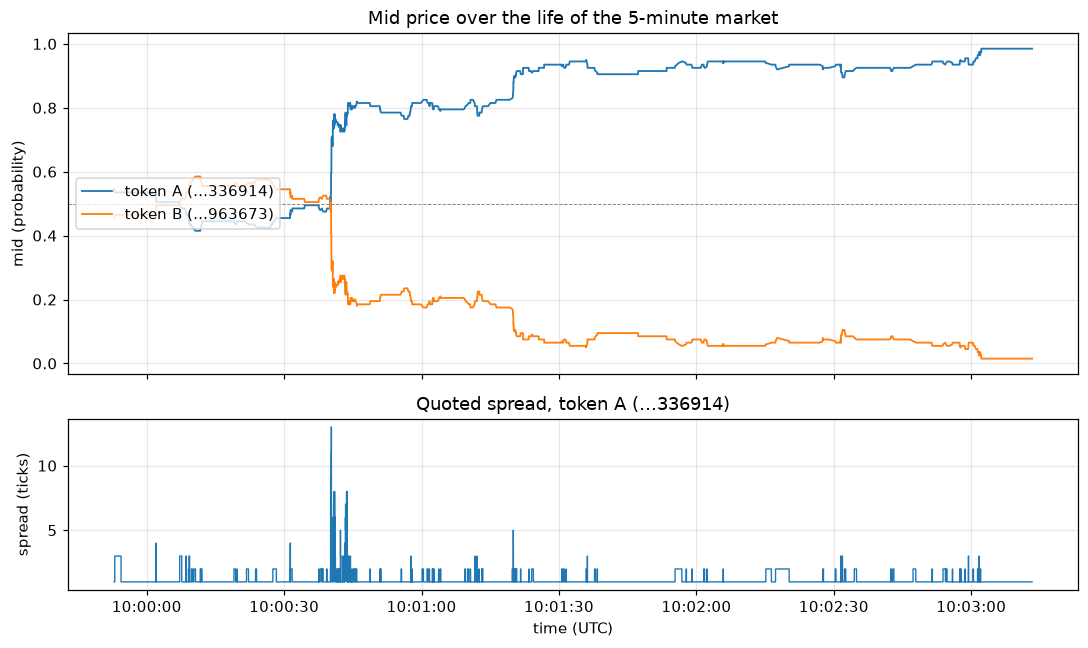

shape: (2, 5)
┌──────────┬────────────────────┬───────────────────┬────────────────┬───────────────────┐
│ mid_open ┆ mid_last_two_sided ┆ mean_spread_ticks ┆ frac_at_1_tick ┆ token             │
│ ---      ┆ ---                ┆ ---               ┆ ---            ┆ ---               │
│ f64      ┆ f64                ┆ f64               ┆ f64            ┆ str               │
╞══════════╪════════════════════╪═══════════════════╪════════════════╪═══════════════════╡
│ 0.545    ┆ 0.985              ┆ 1.493223          ┆ 0.800236       ┆ token A (…336914) │
│ 0.455    ┆ 0.015              ┆ 1.493223          ┆ 0.800236       ┆ token B (…963673) │
└──────────┴────────────────────┴───────────────────┴────────────────┴───────────────────┘


In [6]:
fig, axes = plt.subplots(
    2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)
for aid in ASSETS:
    t = tob.filter((pl.col("asset_id") == aid) & pl.col("mid").is_not_null())
    axes[0].plot(t["time"].to_numpy(), t["mid"].to_numpy(), lw=1.2, label=LABEL[aid])
axes[0].axhline(0.5, color="gray", lw=0.6, ls="--")
axes[0].set_ylabel("mid (probability)")
axes[0].set_title("Mid price over the life of the 5-minute market")
axes[0].legend(loc="center left")

ta = tob.filter((pl.col("asset_id") == ASSETS[0]) & pl.col("spread").is_not_null())
axes[1].plot(
    ta["time"].to_numpy(), (ta["spread"] / TICK).to_numpy(), lw=0.9, drawstyle="steps-post"
)
axes[1].set_ylabel("spread (ticks)")
axes[1].set_xlabel("time (UTC)")
axes[1].set_title(f"Quoted spread, {LABEL[ASSETS[0]]}")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
fig.tight_layout()
plt.show()

two_sided = tob.drop_nulls("mid")
print(
    two_sided.group_by("asset_id")
    .agg(
        pl.col("mid").first().alias("mid_open"),
        pl.col("mid").last().alias("mid_last_two_sided"),
        (pl.col("spread") / TICK).mean().alias("mean_spread_ticks"),
        (pl.col("spread") <= TICK * 1.001).mean().alias("frac_at_1_tick"),
    )
    .with_columns(pl.col("asset_id").replace_strict(LABEL).alias("token"))
    .drop("asset_id")
    .sort("token")
)

The market opened near 0.545 / 0.455 and trended for most of the window before pinning:
token A's mid walks up toward 0.99 while token B mirrors it down toward 0.01. The book
quotes one tick wide most of the time, widening briefly around the sharper mid moves —
consistent with quoting risk rising when the outcome probability is repricing.

## 4. Microprice

The microprice weights each side of the top of book by the *opposite* queue size,

$$P_{micro} = \frac{P_{bid} Q_{ask} + P_{ask} Q_{bid}}{Q_{bid} + Q_{ask}},$$

so it leans toward the side with less resting depth: a thin ask queue pulls the
microprice above mid, anticipating an upward tick. It is a standard short-horizon
fair-value proxy sitting strictly inside the spread.

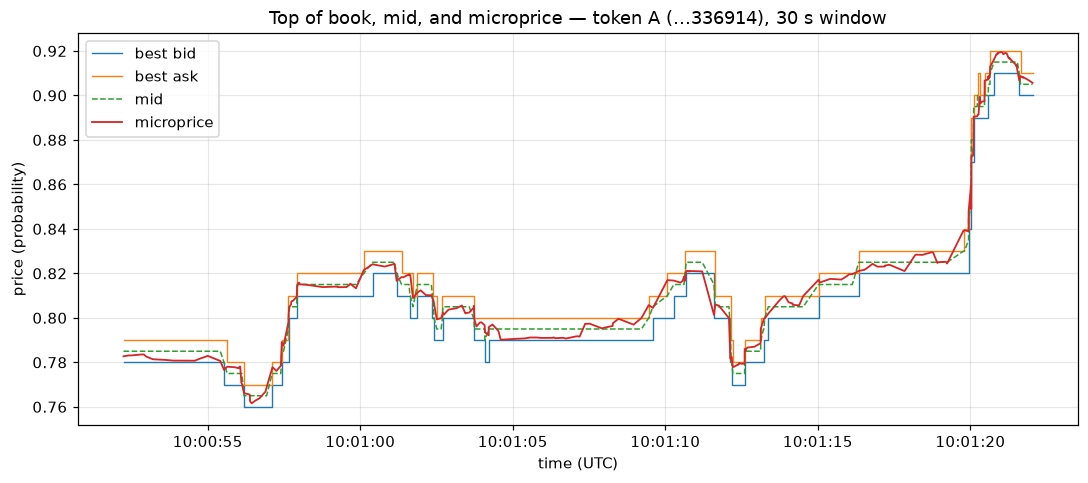

token A (…336914): corr(micro - mid, next mid change) = 0.226 (n=1696); conditioned on a move = 0.329 (n=314)
token B (…963673): corr(micro - mid, next mid change) = 0.226 (n=1696); conditioned on a move = 0.329 (n=315)


In [7]:
tob = tob.with_columns(
    micro=(pl.col("bid") * pl.col("ask_size") + pl.col("ask") * pl.col("bid_size"))
    / (pl.col("bid_size") + pl.col("ask_size"))
)

# 30-second zoom on token A: bid/ask staircase, mid, and microprice.
z0, z1 = t0_us + 60_000_000, t0_us + 90_000_000
z = tob.filter(
    (pl.col("asset_id") == ASSETS[0]) & pl.col("mid").is_not_null() & pl.col("ts").is_between(z0, z1)
)
fig, ax = plt.subplots(figsize=(10, 4.5))
x = z["time"].to_numpy()
ax.step(x, z["bid"].to_numpy(), where="post", lw=0.9, label="best bid")
ax.step(x, z["ask"].to_numpy(), where="post", lw=0.9, label="best ask")
ax.plot(x, z["mid"].to_numpy(), lw=1.0, ls="--", label="mid")
ax.plot(x, z["micro"].to_numpy(), lw=1.2, label="microprice")
ax.set_ylabel("price (probability)")
ax.set_xlabel("time (UTC)")
ax.set_title(f"Top of book, mid, and microprice — {LABEL[ASSETS[0]]}, 30 s window")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
fig.tight_layout()
plt.show()

# Does the microprice skew anticipate the next mid move?
skew = tob.with_columns(
    skew=pl.col("micro") - pl.col("mid"),
    dmid_next=pl.col("mid").shift(-1).over("asset_id") - pl.col("mid"),
).drop_nulls(["skew", "dmid_next"])
for aid in ASSETS:
    s = skew.filter(pl.col("asset_id") == aid)
    r_all = np.corrcoef(s["skew"], s["dmid_next"])[0, 1]
    moved = s.filter(pl.col("dmid_next") != 0)
    r_mv = np.corrcoef(moved["skew"], moved["dmid_next"])[0, 1]
    print(
        f"{LABEL[aid]}: corr(micro - mid, next mid change) = {r_all:.3f} "
        f"(n={len(s)}); conditioned on a move = {r_mv:.3f} (n={len(moved)})"
    )

The microprice hugs whichever side of the spread has the thinner opposing queue and
frequently crosses to the new mid *before* the quote actually ticks. The correlation
between the microprice skew and the next snapshot-to-snapshot mid change is positive and
material for both tokens — the usual result that queue imbalance at the top of book
carries short-horizon directional information, visible even in a five-minute binary
market.

## 5. Order-flow imbalance and short-horizon mid moves

Order-flow imbalance (OFI) nets depth added on the bid side against depth added on the
ask side between consecutive book observations. We follow the event formulation of Cont,
Kukanov and Stoikov, *The Price Impact of Order Book Events* (Journal of Financial
Econometrics 12(1), 2014): between observations $n{-}1$ and $n$, bid-side depth counts
positive when the bid price improves or holds, negative when it retreats, and the ask
side mirrors it:

$$e_n = q^b_n \mathbb{1}_{\{p^b_n \ge p^b_{n-1}\}} - q^b_{n-1} \mathbb{1}_{\{p^b_n \le p^b_{n-1}\}} - q^a_n \mathbb{1}_{\{p^a_n \le p^a_{n-1}\}} + q^a_{n-1} \mathbb{1}_{\{p^a_n \ge p^a_{n-1}\}}$$

CKS define this at the best level; we rank-match the top $K{=}5$ levels between
consecutive snapshots and sum the per-level terms (the usual multi-level extension),
then aggregate into 2-second buckets. Their central result is a *contemporaneous* linear
relation $\Delta P \approx \beta \cdot \mathrm{OFI}$, with $\beta$ inversely related
to market depth. Buckets that touch the one-sided endgame books drop out (no mid).

token A (…336914): dP = 0.291 ticks per 1,000 units of OFI + 0.179, R² = 0.41 (93 buckets)
token B (…963673): dP = 0.291 ticks per 1,000 units of OFI + -0.179, R² = 0.41 (93 buckets)


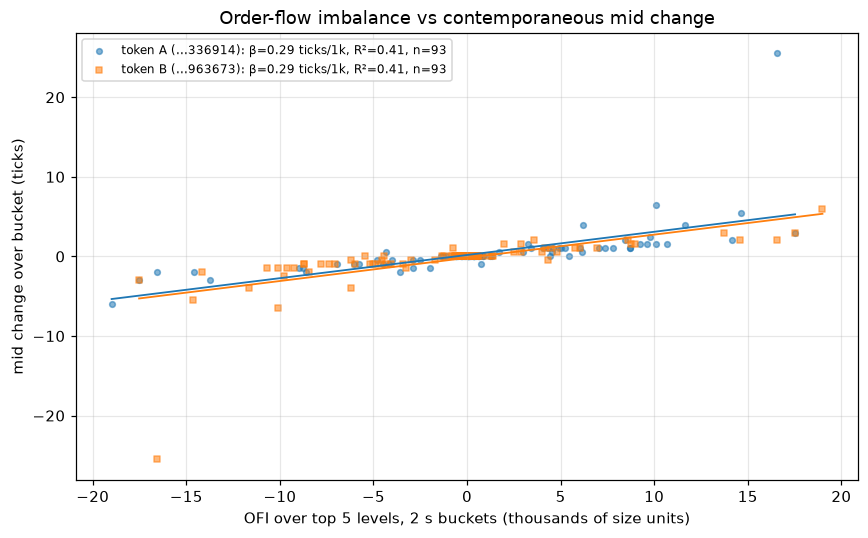

In [8]:
K = 5
BUCKET_US = 2_000_000


def top_levels(side_code: int, best_is_max: bool, prefix: str) -> pl.DataFrame:
    lvl = (
        snap.filter(pl.col("side") == side_code)
        .with_columns(
            rk=pl.col("price").rank("ordinal", descending=best_is_max).over("asset_id", "source_event_id")
        )
        .filter(pl.col("rk") <= K)
        .select(
            "asset_id",
            "source_event_id",
            pl.col("recv_timestamp_us").alias("ts"),
            "rk",
            (pl.col("price") / PRICE_SCALE).alias(f"{prefix}px"),
            (pl.col("size") / SIZE_SCALE).alias(f"{prefix}sz"),
        )
    )
    return lvl.pivot(
        on="rk", index=["asset_id", "source_event_id", "ts"], values=[f"{prefix}px", f"{prefix}sz"]
    )


lvls = (
    top_levels(BID, True, "b")
    .join(top_levels(ASK, False, "a"), on=["asset_id", "source_event_id", "ts"])
    .sort("asset_id", "ts")
)

terms = []
for m in range(1, K + 1):
    bpx, bsz = pl.col(f"bpx_{m}"), pl.col(f"bsz_{m}")
    apx, asz = pl.col(f"apx_{m}"), pl.col(f"asz_{m}")
    bpx_p, bsz_p = bpx.shift(1).over("asset_id"), bsz.shift(1).over("asset_id")
    apx_p, asz_p = apx.shift(1).over("asset_id"), asz.shift(1).over("asset_id")
    e_bid = bsz * (bpx >= bpx_p).cast(pl.Float64) - bsz_p * (bpx <= bpx_p).cast(pl.Float64)
    e_ask = -asz * (apx <= apx_p).cast(pl.Float64) + asz_p * (apx >= apx_p).cast(pl.Float64)
    terms.append(e_bid + e_ask)

# reduce(add) propagates nulls, so partially-filled endgame books drop out cleanly
ofi = (
    lvls.with_columns(ofi=reduce(add, terms))
    .drop_nulls("ofi")
    .select("asset_id", "ts", "ofi")
)

ofi_b = (
    ofi.with_columns(bucket=(pl.col("ts") - t0_us) // BUCKET_US)
    .group_by("asset_id", "bucket")
    .agg(pl.col("ofi").sum())
)
mid_b = (
    tob.drop_nulls("mid")
    .with_columns(bucket=(pl.col("ts") - t0_us) // BUCKET_US)
    .group_by("asset_id", "bucket")
    .agg(pl.col("mid").last())
    .sort("asset_id", "bucket")
    .with_columns(dmid_ticks=(pl.col("mid") - pl.col("mid").shift(1).over("asset_id")) / TICK)
)
reg = ofi_b.join(mid_b, on=["asset_id", "bucket"]).drop_nulls().sort("asset_id", "bucket")

fig, ax = plt.subplots(figsize=(8, 5))
for aid, marker in zip(ASSETS, ["o", "s"]):
    r = reg.filter(pl.col("asset_id") == aid)
    x = r["ofi"].to_numpy() / 1e3
    y = r["dmid_ticks"].to_numpy()
    slope, intercept = np.polyfit(x, y, 1)
    r2 = np.corrcoef(x, y)[0, 1] ** 2
    ax.scatter(x, y, s=14, alpha=0.55, marker=marker, label=f"{LABEL[aid]}: β={slope:.2f} ticks/1k, R²={r2:.2f}, n={len(r)}")
    xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, slope * xs + intercept, lw=1.2)
    print(f"{LABEL[aid]}: dP = {slope:.3f} ticks per 1,000 units of OFI + {intercept:.3f}, R² = {r2:.2f} ({len(r)} buckets)")
ax.set_xlabel(f"OFI over top {K} levels, 2 s buckets (thousands of size units)")
ax.set_ylabel("mid change over bucket (ticks)")
ax.set_title("Order-flow imbalance vs contemporaneous mid change")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

The relation is visibly linear with a positive slope for both tokens, in line with CKS —
even here, on a five-minute binary market, bucketed OFI explains a meaningful share of
contemporaneous mid variance, and the two complementary tokens produce near-identical
fits (as they must, since their books mirror each other). The obvious caveat: 300
seconds of one market is a demonstration that the capture supports this analysis, not an
estimate anyone should trade on.

## 6. Trade flow and spread capture

`trade_events` carries every print with its price, size, and — where the venue reports
it — the aggressor side (`side`: 1 = taker buy, 2 = taker sell; the column is nullable
and `fidelity` flags degraded prints, but in this capture every print is `fidelity=full`
and carries a side).

Two standard per-trade quantities, using the prevailing snapshot mid $m_t$ and the mid
ten seconds later:

- **effective spread** $= 2d(p - m_t)$ — what the aggressor paid to cross, and
- **realized spread** $= 2d(p - m_{t+10s})$ — what the passive side actually kept after
  the market moved; the difference is adverse selection.

with $d = +1$ for taker buys, $-1$ for taker sells.

shape: (4, 4)
┌───────────────────┬────────────┬────────┬─────────┐
│ token             ┆ side       ┆ trades ┆ volume  │
│ ---               ┆ ---        ┆ ---    ┆ ---     │
│ str               ┆ str        ┆ u32    ┆ f64     │
╞═══════════════════╪════════════╪════════╪═════════╡
│ token A (…336914) ┆ taker buy  ┆ 964    ┆ 26002.0 │
│ token A (…336914) ┆ taker sell ┆ 107    ┆ 2511.0  │
│ token B (…963673) ┆ taker buy  ┆ 491    ┆ 40932.0 │
│ token B (…963673) ┆ taker sell ┆ 66     ┆ 1147.0  │
└───────────────────┴────────────┴────────┴─────────┘


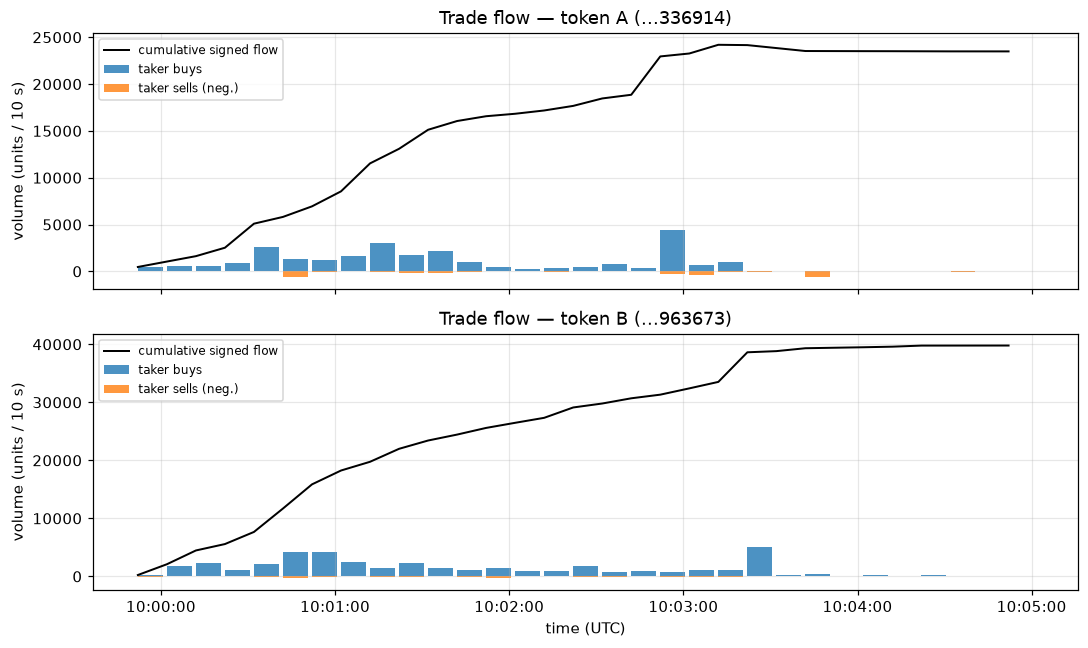

In [9]:
tr = (
    trades.select(
        "asset_id",
        pl.col("recv_timestamp_us").alias("ts"),
        (pl.col("price") / PRICE_SCALE).alias("px"),
        (pl.col("size").cast(pl.Float64) / SIZE_SCALE).alias("qty"),
        pl.when(pl.col("side") == BID).then(1.0).when(pl.col("side") == ASK).then(-1.0).alias("sign"),
    )
    .with_columns(time=pl.from_epoch(pl.col("ts").cast(pl.Int64), time_unit="us"))
    .sort("ts")
)

print(
    tr.group_by("asset_id", "sign")
    .agg(pl.len().alias("trades"), pl.col("qty").sum().round(0).alias("volume"))
    .with_columns(
        pl.col("asset_id").replace_strict(LABEL).alias("token"),
        pl.col("sign").replace_strict({1.0: "taker buy", -1.0: "taker sell"}).alias("side"),
    )
    .select("token", "side", "trades", "volume")
    .sort("token", "side")
)

TRADE_BUCKET_US = 10_000_000
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for ax, aid in zip(axes, ASSETS):
    t = tr.filter(pl.col("asset_id") == aid).with_columns(
        bucket=((pl.col("ts") - t0_us) // TRADE_BUCKET_US)
    )
    b = (
        t.group_by("bucket")
        .agg(
            pl.col("qty").filter(pl.col("sign") == 1).sum().alias("buy"),
            (-pl.col("qty").filter(pl.col("sign") == -1).sum()).alias("sell"),
            (pl.col("qty") * pl.col("sign")).sum().alias("signed"),
        )
        .sort("bucket")
        .with_columns(t=pl.from_epoch((t0_us + pl.col("bucket") * TRADE_BUCKET_US).cast(pl.Int64), time_unit="us"))
    )
    x = b["t"].to_numpy()
    width = np.timedelta64(TRADE_BUCKET_US, "us") * 0.85
    ax.bar(x, b["buy"].to_numpy(), width=width, align="edge", label="taker buys", alpha=0.8)
    ax.bar(x, b["sell"].to_numpy(), width=width, align="edge", label="taker sells (neg.)", alpha=0.8)
    ax.plot(x, b["signed"].cum_sum().to_numpy(), lw=1.3, color="black", label="cumulative signed flow")
    ax.set_ylabel("volume (units / 10 s)")
    ax.set_title(f"Trade flow — {LABEL[aid]}")
    ax.legend(fontsize=8, loc="upper left")
axes[1].set_xlabel("time (UTC)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
fig.tight_layout()
plt.show()

In [10]:
HORIZON_US = 10_000_000
mids = tob.drop_nulls("mid").select("asset_id", "ts", "mid").sort("ts")

# both frames are sorted on the asof key by construction (see the .sort calls),
# which polars cannot verify per by-group, hence check_sortedness=False
spread_capture = (
    tr.join_asof(mids, on="ts", by="asset_id", strategy="backward", check_sortedness=False)
    .with_columns(ts_fwd=pl.col("ts") + HORIZON_US)
    .sort("ts_fwd")
    .join_asof(
        mids.rename({"ts": "ts_fwd", "mid": "mid_fwd"}),
        on="ts_fwd",
        by="asset_id",
        strategy="backward",
        check_sortedness=False,
    )
    # require a two-sided book at the trade and a full horizon inside the capture
    .filter(pl.col("mid").is_not_null() & pl.col("mid_fwd").is_not_null() & (pl.col("ts_fwd") <= t1_us))
    .with_columns(
        eff_ticks=2 * pl.col("sign") * (pl.col("px") - pl.col("mid")) / TICK,
        rlzd_ticks=2 * pl.col("sign") * (pl.col("px") - pl.col("mid_fwd")) / TICK,
    )
)

(
    spread_capture.group_by("asset_id")
    .agg(
        pl.len().alias("trades"),
        (pl.col("sign") == 1).mean().round(3).alias("buy_share"),
        pl.col("eff_ticks").mean().round(2).alias("mean_effective"),
        pl.col("rlzd_ticks").mean().round(2).alias("mean_realized_10s"),
        (pl.col("eff_ticks") - pl.col("rlzd_ticks")).mean().round(2).alias("adverse_selection"),
    )
    .with_columns(pl.col("asset_id").replace_strict(LABEL).alias("token"))
    .drop("asset_id")
    .sort("token")
)

trades,buy_share,mean_effective,mean_realized_10s,adverse_selection,token
u32,f64,f64,f64,f64,str
1069,0.902,1.19,-4.82,6.01,"""token A (…336914)"""
556,0.881,1.06,5.73,-4.67,"""token B (…963673)"""


Taker flow is heavily buy-skewed on both tokens — which is only superficially a paradox:
buying the down-token is economically equivalent to selling the up-token, so two-sided
opinion shows up as taker buys on opposite legs. The effective spread sits around one
tick, as expected for a book quoting at the minimum increment. The realized spread is
strongly negative: on average the market kept moving *through* the aggressor's side over
the next ten seconds, i.e. this capture's taker flow was informed and passive fills were
adversely selected — exactly what one expects in the final minutes of a short-dated
binary market where the underlying (BTC) is publicly observable.

## 7. Binary-outcome dynamics

The two tokens are complementary claims on the same event, so their probabilities should
sum to one; persistent deviation would be internal arbitrage (ignoring fees). And as
resolution approaches certainty, the books should *pin*: nobody bids for the losing
claim, nobody offers the winning one, so the losing book's bid side and the winning
book's ask side empty out and quotes saturate at the 0.01 / 0.99 boundary ticks.

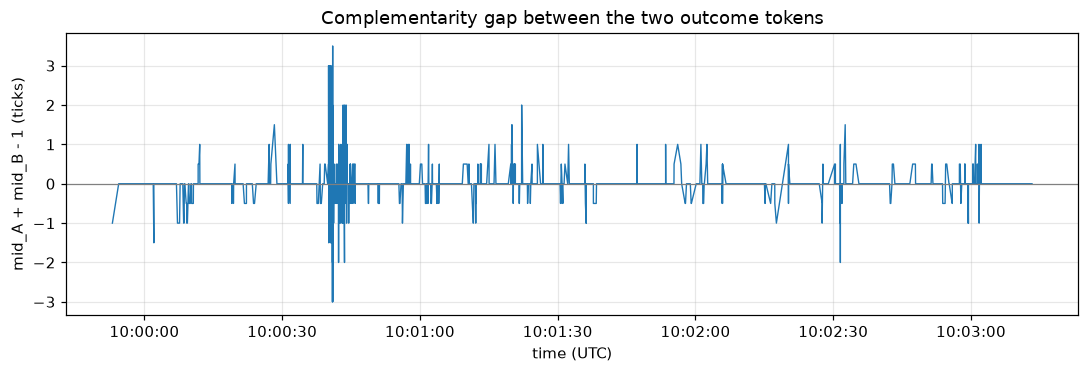

complementarity gap: mean +0.03 ticks | std 0.41 | max |dev| 3.5 ticks

endgame pinning:
  token A (…336914): first one-sided snapshot 10:03:13 UTC | final book: bid=0.99 (91 levels), ask=- (0 levels)
  token B (…963673): first one-sided snapshot 10:03:13 UTC | final book: bid=- (0 levels), ask=0.01 (91 levels)


In [11]:
mid_a = tob.filter(pl.col("asset_id") == ASSETS[0]).drop_nulls("mid").select("ts", "time", "mid").sort("ts")
mid_b2 = tob.filter(pl.col("asset_id") == ASSETS[1]).drop_nulls("mid").select("ts", pl.col("mid").alias("mid_b")).sort("ts")
pair = mid_a.join_asof(mid_b2, on="ts", strategy="backward").drop_nulls()
pair = pair.with_columns(dev_ticks=(pl.col("mid") + pl.col("mid_b") - 1.0) / TICK)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(pair["time"].to_numpy(), pair["dev_ticks"].to_numpy(), lw=0.9)
ax.axhline(0, color="gray", lw=0.8)
ax.set_ylabel("mid_A + mid_B - 1 (ticks)")
ax.set_xlabel("time (UTC)")
ax.set_title("Complementarity gap between the two outcome tokens")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
fig.tight_layout()
plt.show()

print(
    f"complementarity gap: mean {pair['dev_ticks'].mean():+.2f} ticks | "
    f"std {pair['dev_ticks'].std():.2f} | max |dev| {pair['dev_ticks'].abs().max():.1f} ticks"
)

print("\nendgame pinning:")
fmt_px = lambda v: "-" if v is None else f"{v:.2f}"
for aid in ASSETS:
    t = tob.filter(pl.col("asset_id") == aid).sort("ts")
    one_sided = t.filter(pl.col("bid").is_null() | pl.col("ask").is_null())
    first_pin = utc(one_sided["ts"].min()) if len(one_sided) else None
    last = t.tail(1).to_dicts()[0]
    print(
        f"  {LABEL[aid]}: first one-sided snapshot {first_pin:%H:%M:%S} UTC | final book: "
        f"bid={fmt_px(last['bid'])} ({last['bid_levels']} levels), "
        f"ask={fmt_px(last['ask'])} ({last['ask_levels']} levels)"
    )

The complementarity gap stays within a tick of zero for nearly the whole window — the
two books are kept consistent to roughly the quoting increment. In the endgame the
capture shows textbook pinning: token A's final snapshots quote a 0.99 bid with an empty
ask side, token B a 0.01 ask with an empty bid side. The mid is undefined from that
point, which is why the earlier series end before the capture does. Anyone building
signals on binary markets has to special-case this regime; the capture preserves it
faithfully rather than smoothing it away.

## 8. Takeaways

- The committed capture is directly consumable by standard tooling: everything above is
  polars + matplotlib over the raw Parquet tree, with the fixed-point decode as the only
  poly-book-specific knowledge required.
- Venue snapshots arrive densely enough (median ~40 ms) that an honest, replay-free
  top-of-book series supports mid/spread, microprice, OFI, and trade-flow analytics at
  sub-second resolution. For exact book states between snapshots, use the tested replay
  path (`GET /api/v1/replay/reconstruct`, or `poly-book replay`) instead of
  re-implementing delta application ad hoc.
- The microstructure of a 5-minute binary market behaves like textbook microstructure —
  queue imbalance and OFI carry short-horizon information, effective spreads sit at the
  tick, realized spreads show heavy adverse selection — with one regime standard
  equity-style analytics must special-case: terminal pinning, where one side of each
  book empties and mid/spread stop existing.
- `examples/api-cookbook.md` exercises every HTTP/WS route against this same capture via
  `poly-book demo`.